# Neural Network Fitting (Appendix File)

##### Project Note – Python Versions and TensorFlow Compatibility

This project is composed of two separate parts due to **Python version compatibility constraints**.

The **main project file** is written using **Python 3.13**, which is used for the overall data analysis, modeling, and evaluation pipeline.  
However, **TensorFlow is not compatible with Python 3.13**, and therefore training a neural network requires using **Python 3.10**.

To address this limitation, the project is structured as follows:

- **Main file (Python 3.13)**  
  - Data exploration  
  - Feature engineering  
  - All methods we used unless DNN  

- **Supplementary file (Python 3.10)**  
  - Data preprocessing  
  - Feature selection using **Lasso regression**  
  - Neural network training using **TensorFlow**  

The Lasso model is used to select a subset of relevant variables, and these selected features are then reused as inputs for one of the neural network fittings.

This separation ensures:
- Full compatibility with TensorFlow
- A clean and reproducible workflow
- No compromise on using the latest Python version for the main project

Both files together constitute the complete machine learning pipeline.

In [46]:
import sys
import tensorflow as tf

#Display if Tensorflow is correctly imported 
print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)

Python: /Users/ayamarkous/Desktop/ML 2025/MLProject/venv/bin/python
TensorFlow: 2.20.0


#### Libraries Used in this file 

- `TensorFlow`: used to implement and train neural network models capable of capturing complex, non-linear relationships in meteorological data across multiple weather stations.

- `Keras` from Tensorflow: used as a high-level interface to efficiently design, train, and tune neural networks for temperature forecasting tasks.

*All other libraries used in this notebook have already been described and justified in the main notebook.*

In [47]:
# Data handling
import pandas as pd 

# Numerical operations
import numpy as np    

# Basic visualization (optional)
import matplotlib.pyplot as plt  # Basic visualization 

# For filling missing values 
from sklearn.impute import SimpleImputer  

 # For feature scaling
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.pipeline import Pipeline

In [48]:
# Load the training dataset 
train_weather_data = pd.read_csv('/Users/ayamarkous/Desktop/ML 2025/MLProject/train.csv', sep =',')


# Display dataset shape (rows, columns)
print("Shape:", train_weather_data.shape)

# Display first rows of the dataset
train_weather_data.head()

Shape: (7579, 92)


,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,fkl010h0_STG,fkl010h0_ZER,...,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0,tre200h0_lag24h,target_tre200h0_plus12h,target_tre200h0_plus24h,target_tre200h0_plus48h,hour,season
0,1.3,2.1,0.8,8.3,1.0,0.6,0.6,0.5,3.4,0.9,...,84.4,76.0,74.0,12.2,8.5,17.5,10.3,10.0,5.0,Spring
1,3.8,0.8,3.8,14.0,6.9,0.5,2.9,0.6,2.0,1.8,...,87.6,96.3,67.4,4.3,8.9,12.1,1.5,6.3,3.0,Spring
2,1.1,2.0,0.1,10.5,2.1,1.3,1.1,1.7,0.9,1.1,...,81.9,96.5,65.8,-12.3,-7.6,-7.1,-3.5,-2.1,0.0,Winter
3,0.8,3.1,1.8,9.8,1.0,1.9,0.8,0.8,0.5,0.8,...,46.4,83.9,33.7,5.6,8.2,3.2,7.4,6.5,13.0,Autumn
4,4.4,1.6,4.3,2.9,2.2,2.8,6.3,5.4,1.0,2.8,...,39.4,65.7,44.7,20.7,19.2,15.7,21.9,23.9,11.0,Summer


# 3. Data Preprocessing (From main notebook)

For this section, we have made some adjustments in order to get a more coherent data set. Season and hour column are the main features concerned as their categorical type doesn't match with the overall structure of the data set.
Some further features engineering were made (see below).

In [49]:
# NUMERIC IMPUTATION

# We first select numeric columns from the dataset and impute missing values using the median.
# Median imputation is robust to outliers and ensures that correlation calculations are reliable.
numeric_df = train_weather_data.select_dtypes(include=['float64','int64'])
imputer = SimpleImputer(strategy='median')
numeric_df_imputed = pd.DataFrame(imputer.fit_transform(numeric_df),
                                  columns=numeric_df.columns)

# Define target variables for correlation analysis
targets = [
    'target_tre200h0_plus12h',
    'target_tre200h0_plus24h',
    'target_tre200h0_plus48h'
]

numeric_df_imputed.head()

,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,fkl010h0_STG,fkl010h0_ZER,...,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0,tre200h0_lag24h,target_tre200h0_plus12h,target_tre200h0_plus24h,target_tre200h0_plus48h,hour
0,1.3,2.1,0.8,8.3,1.0,0.6,0.6,0.5,3.4,0.9,...,78.5,84.4,76.0,74.0,12.2,8.5,17.5,10.3,10.0,5.0
1,3.8,0.8,3.8,14.0,6.9,0.5,2.9,0.6,2.0,1.8,...,36.0,87.6,96.3,67.4,4.3,8.9,12.1,1.5,6.3,3.0
2,1.1,2.0,0.1,10.5,2.1,1.3,1.1,1.7,0.9,1.1,...,50.6,81.9,96.5,65.8,-12.3,-7.6,-7.1,-3.5,-2.1,0.0
3,0.8,3.1,1.8,9.8,1.0,1.9,0.8,0.8,0.5,0.8,...,57.2,46.4,83.9,33.7,5.6,8.2,3.2,7.4,6.5,13.0
4,4.4,1.6,4.3,2.9,2.2,2.8,6.3,5.4,1.0,2.8,...,28.9,39.4,65.7,44.7,20.7,19.2,15.7,21.9,23.9,11.0


In [50]:
# Select season categorical column
cat_cols = ["season"]

# Copy original categorical data
categorical_df = train_weather_data[cat_cols].copy()

# Impute categorical NA with mode (most frequent value)
categorical_df = categorical_df.fillna(categorical_df.mode().iloc[0])

Missing values in categorical variables were imputed using the mode. Since categorical features do not have a numerical ordering, mode imputation provides a simple and consistent strategy that preserves the dominant seasonal structure of the dataset without introducing artificial categories.

In [51]:
# Combine the imputed numerical features with the imputed categorical features by concatenating them
train_weather_data_clean = pd.concat([numeric_df_imputed, categorical_df], axis=1)

# Verify that both DataFrames share the same index to ensure correct row matching, return True if it concatenate correctly
print(numeric_df_imputed.index.equals(categorical_df.index)) 

# numeric imputation was done in the correlation analysis (section above)

True


 ##### Cyclic Encoding
 Feature engineering for the "hour" column 

Encode the hour variable using sine and cosine transformations is the best option in order to preserve its cyclic nature (0–23).

In [52]:
# Since hour column is cyclic (0-23), sin/cos encoding is appropriate
train_weather_data_clean["hour_sin"] = np.sin(2 * np.pi * train_weather_data_clean["hour"] / 24)
train_weather_data_clean["hour_cos"] = np.cos(2 * np.pi * train_weather_data_clean["hour"] / 24)

# Remove the original hour column to avoid misleading linear relationships
train_weather_data_clean = train_weather_data_clean.drop(columns=["hour"])

##### One-hot encoding
Feature engineering for the "season" column :

One-hot-encoding enriches the dataset by introducing seasonal effects, nonlinear temperature relationships, and spatial interactions between Bern and other Swiss weather stations. This allows the models to better capture the complex dynamics governing temperature evolution and therefore improve the predictive performance.

In [53]:
# Convert the categorical variable "season" into dummy (binary) variables
train_weather_data_clean = pd.get_dummies(
    train_weather_data_clean,
    columns=["season"],
    drop_first=True  # avoids dummy variable trap (multicollinearity)
) 
# Define the columns for which polynomial features will be created
poly_cols = [
    'tre200h0', 'tre200h0_BAS', 'tre200h0_INT', 'tre200h0_GVE', 'tre200h0_SIO',
    'tre200h0_ZER', 'tre200h0_LUG', 'tre200h0_STG', 'tre200h0_DAV',
    'tre200h0_ANT', 'tre200h0_DOL'
]
# Identify boolean (True/False) columns, typically created by one-hot encoding
train_weather_data_clean.select_dtypes('bool').columns

Index(['season_Spring', 'season_Summer', 'season_Winter'], dtype='object')

##### Advanced features engineering


These features provide the models with a more informative and structured representation of the meteorological system, for the purpose of improving temperature forecasting performance.

In [54]:
# List of weather stations used to compute spatial aggregates
stations = ['ANT','BAS','DAV','DOL','GVE','INT','LUG','SIO','STG','ZER']

# Build the list of temperature columns for all stations
temp_cols = [f"tre200h0_{s}" for s in stations]
# Compute the mean temperature across all stations
train_weather_data_clean["temp_mean"] = train_weather_data_clean[temp_cols].mean(axis=1)
# Compute the temperature range (max - min) across stations
train_weather_data_clean["temp_range"] = (
    train_weather_data_clean[temp_cols].max(axis=1)
    - train_weather_data_clean[temp_cols].min(axis=1)
)

# Compute Bern temperature anomaly relative to the national mean
train_weather_data_clean["bern_temp_anomaly"] = (
    train_weather_data_clean["tre200h0"]
    - train_weather_data_clean["temp_mean"]
)

# Compute the 24-hour temperature change in Bern
train_weather_data_clean["delta_temp_24h"] = (
    train_weather_data_clean["tre200h0"]
    - train_weather_data_clean["tre200h0_lag24h"]
)

# Build the list of humidity columns for all stations
hum_cols = [f"ure200h0_{s}" for s in stations]
# Compute the mean humidity across stations
train_weather_data_clean["humidity_mean"] = train_weather_data_clean[hum_cols].mean(axis=1)

# Build the list of wind speed columns for all stations
wind_cols = [f"fkl010h0_{s}" for s in stations]
# Compute the mean wind speed across stations
train_weather_data_clean["wind_mean"] = train_weather_data_clean[wind_cols].mean(axis=1)

# Display the final dataset shape after all features engineering
print("Final shape after features engineering:", train_weather_data_clean.shape)
train_weather_data_clean.head()

Final shape after features engineering: (7579, 101)


,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,fkl010h0_STG,fkl010h0_ZER,...,hour_cos,season_Spring,season_Summer,season_Winter,temp_mean,temp_range,bern_temp_anomaly,delta_temp_24h,humidity_mean,wind_mean
0,1.3,2.1,0.8,8.3,1.0,0.6,0.6,0.5,3.4,0.9,...,0.258819,True,False,False,10.08,8.7,2.12,3.7,84.19,1.95
1,3.8,0.8,3.8,14.0,6.9,0.5,2.9,0.6,2.0,1.8,...,0.707107,True,False,False,3.30,15.9,1.00,-4.6,81.60,3.71
2,1.1,2.0,0.1,10.5,2.1,1.3,1.1,1.7,0.9,1.1,...,1.000000,False,False,True,-10.48,19.6,-1.82,-4.7,68.09,2.19
3,0.8,3.1,1.8,9.8,1.0,1.9,0.8,0.8,0.5,0.8,...,-0.965926,False,False,False,5.46,6.5,0.14,-2.6,53.15,2.13
4,4.4,1.6,4.3,2.9,2.2,2.8,6.3,5.4,1.0,2.8,...,-0.965926,False,True,False,17.89,15.8,2.81,1.5,56.32,3.37


In [55]:
#Convert boolean dummy variables (True/False) into numerical format (0/1) for model compatibility
bool_cols = train_weather_data_clean.select_dtypes('bool').columns
train_weather_data_clean[bool_cols] = train_weather_data_clean[bool_cols].astype(int) #we need to use onehotencoder 

In [56]:
# Separate the feature matrix (X) from the target variables
X = train_weather_data_clean.drop(columns=targets)

# Define target vectors for the three prediction horizons
y_12 = train_weather_data_clean["target_tre200h0_plus12h"]
y_24 = train_weather_data_clean["target_tre200h0_plus24h"]
y_48 = train_weather_data_clean["target_tre200h0_plus48h"]

# Display the dimensions of the feature matrix and target vectors
print("Feature matrix shape:", X.shape)
print("Target vector shapes:", y_12.shape, y_24.shape, y_48.shape)

Feature matrix shape: (7579, 98)
Target vector shapes: (7579,) (7579,) (7579,)


##### Train/Test split for each target variable +12h, +24h and +48h

In [57]:
from sklearn.model_selection import train_test_split

# Split for +12h target
X_train_12, X_test_12, y_train_12, y_test_12 = train_test_split(
    X, y_12, test_size=0.2, random_state=42
)

# Split for +24h target
X_train_24, X_test_24, y_train_24, y_test_24 = train_test_split(
    X, y_24, test_size=0.2, random_state=42
)

# Split for +48h target
X_train_48, X_test_48, y_train_48, y_test_48 = train_test_split(
    X, y_48, test_size=0.2, random_state=42
)


In [58]:
# Initialize a standard scaler to normalize features (mean = 0, std = 1)
# The same scaler is reused since all prediction horizons share the same feature space
scaler = StandardScaler()

# Fit only on training data (important to avoid data leakage)
scaler.fit(X_train_12)  
 # The scaler is fitted only once on the training data to avoid data leakage, and the same fitted scaler is reused 
 # for the 24h, and 48h targets since they share identical input features


# Apply the learned scaling parameters to training and test sets
X_train_12_scaled = scaler.transform(X_train_12)
X_test_12_scaled  = scaler.transform(X_test_12)

X_train_24_scaled = scaler.transform(X_train_24)
X_test_24_scaled  = scaler.transform(X_test_24)

X_train_48_scaled = scaler.transform(X_train_48)
X_test_48_scaled  = scaler.transform(X_test_48)

# Store column names to preserve feature labels after scaling
colnames = X_train_12.columns

# Convert scaled NumPy arrays back into DataFrames for interpretability and consistency
X_train_12_scaled = pd.DataFrame(X_train_12_scaled, columns=colnames)
X_test_12_scaled  = pd.DataFrame(X_test_12_scaled,  columns=colnames)

X_train_24_scaled = pd.DataFrame(X_train_24_scaled, columns=colnames)
X_test_24_scaled  = pd.DataFrame(X_test_24_scaled,  columns=colnames)

X_train_48_scaled = pd.DataFrame(X_train_48_scaled, columns=colnames)
X_test_48_scaled  = pd.DataFrame(X_test_48_scaled,  columns=colnames)


###  Lasso Regression with Cross-Validation
Lasso Regression is a linear model with L1 regularization that automatically selects important features by setting some coefficients to zero.
This function builds a **Lasso Regression pipeline** to perform feature selection and model evaluation.  
It combines preprocessing, hyperparameter tuning, visualization, and performance assessment in a clean workflow.

###  Key Steps
- **Standardization** of features using `StandardScaler`  
- **Hyperparameter tuning** (`alpha`) via `GridSearchCV` with 10-fold cross-validation  
- Selection of optimal `alpha` using the **1-SE rule** for stability 

- **Visualization** of:
  - Cross-validation error curve  
  - Lasso coefficient path  
- Final model fitted with the chosen `alpha`  
- Extraction of selected features and their coefficients  
- Evaluation metric on train and test sets: **MAE**

###  Libraries Used
This code uses **scikit-learn** for building the Lasso pipeline, scaling, cross-validation, hyperparameter tuning, and performance evaluation.

The function returns optimal parameters, selected features, coefficients, and performance metrics, ensuring both **interpretability** and **predictive accuracy**.


In [59]:
from sklearn.linear_model import Lasso           
from sklearn.model_selection import GridSearchCV, KFold  
from sklearn.metrics import mean_squared_error, mean_absolute_error  

def run_lasso_full(X_train, y_train, X_test, y_test, label, alpha_grid=None):
   

    if alpha_grid is None:
        alpha_grid = 10 ** np.linspace(-2.6, 1.7, 100)

    print(f"\n================ LASSO MODEL ({label}) ================\n")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=3000))
    ])

    # GridSearchCV
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    grid = {"lasso__alpha": alpha_grid}

    lassoCV = GridSearchCV(pipe, param_grid=grid, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    lassoCV.fit(X_train, y_train)

    mean_scores = -lassoCV.cv_results_["mean_test_score"]
    std_scores = lassoCV.cv_results_["std_test_score"]
    se_scores = std_scores / np.sqrt(cv.get_n_splits())

    best_idx = np.argmin(mean_scores)
    best_alpha = alpha_grid[best_idx]
    best_mse = mean_scores[best_idx]

    # 1-SE rule
    threshold = best_mse + se_scores[best_idx]
    one_se_alpha = np.max(alpha_grid[mean_scores <= threshold])

    
    # Plot CV error curve
    
    plt.figure(figsize=(10,6))
    plt.errorbar(alpha_grid, mean_scores, yerr=se_scores, fmt="o", capsize=3)
    plt.axvline(best_alpha, color="red", ls="--", label=f"Best alpha = {best_alpha:.4f}")
    plt.axvline(one_se_alpha, color="green", ls="--", label=f"1-SE alpha = {one_se_alpha:.4f}")
    plt.axhline(threshold, color="grey", ls="--")
    plt.xscale("log")
    plt.xlabel("alpha (log)")
    plt.ylabel("MSE")
    plt.title(f"Lasso CV Error Curve ({label})")
    plt.legend()
    plt.show()

    
    # Lasso path
   
    coefs = []
    for a in alpha_grid:
        temp = Pipeline([
            ("scaler", StandardScaler()),
            ("lasso", Lasso(alpha=a, max_iter=3000))
        ])
        temp.fit(X_train, y_train)
        coefs.append(temp.named_steps["lasso"].coef_)

    coefs = np.array(coefs)
    plt.figure(figsize=(12,7))
    plt.plot(alpha_grid, coefs)
    plt.xscale("log")
    plt.xlabel(r"$\alpha$")
    plt.ylabel("Coefficients")
    plt.title(f"Lasso Path ({label})")
    plt.legend(X_train.columns, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()

   
    # Fit final Lasso (1-SE alpha)
    
    final_lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=one_se_alpha, max_iter=3000))
    ])
    final_lasso.fit(X_train, y_train)

    # Obtain the coefficients and selected features

    coef_series = pd.Series(final_lasso.named_steps["lasso"].coef_, index=X_train.columns)
    selected_features = coef_series[coef_series != 0].index.tolist()

    print(f"Best alpha = {best_alpha}")
    print(f"1-SE alpha = {one_se_alpha}")
    print(f"Nombre de variables sélectionnées : {len(selected_features)}")
    print("Variables sélectionnées :", selected_features)

    
    y_train_pred = final_lasso.predict(X_train)
    y_test_pred  = final_lasso.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test  = mean_squared_error(y_test, y_test_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test  = mean_absolute_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)

    print(f"\nTRAIN → MAE: {mae_train:.4f}")
    print(f"TEST  → MAE: {mae_test:.4f}")


    return {
        "best_alpha": best_alpha,
        "one_se_alpha": one_se_alpha,
        "selected_features": selected_features,
        "coefficients": coef_series,
        "model": final_lasso,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "mae_train": mae_train,
        "mae_test": mae_test,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test
    }


================ LASSO MODEL (12h) ================



/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.448e+03, tolerance: 3.674e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.732e+03, tolerance: 3.708e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

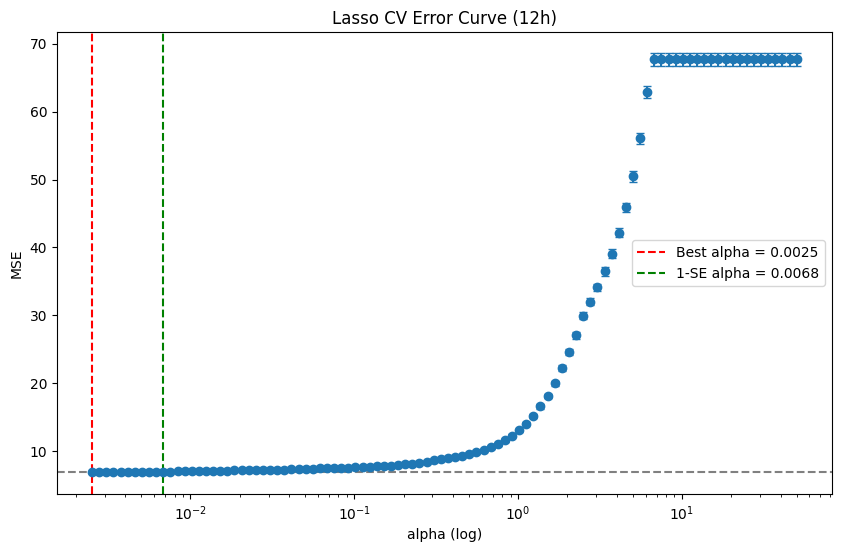

/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.273e+03, tolerance: 4.104e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.976e+03, tolerance: 4.104e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

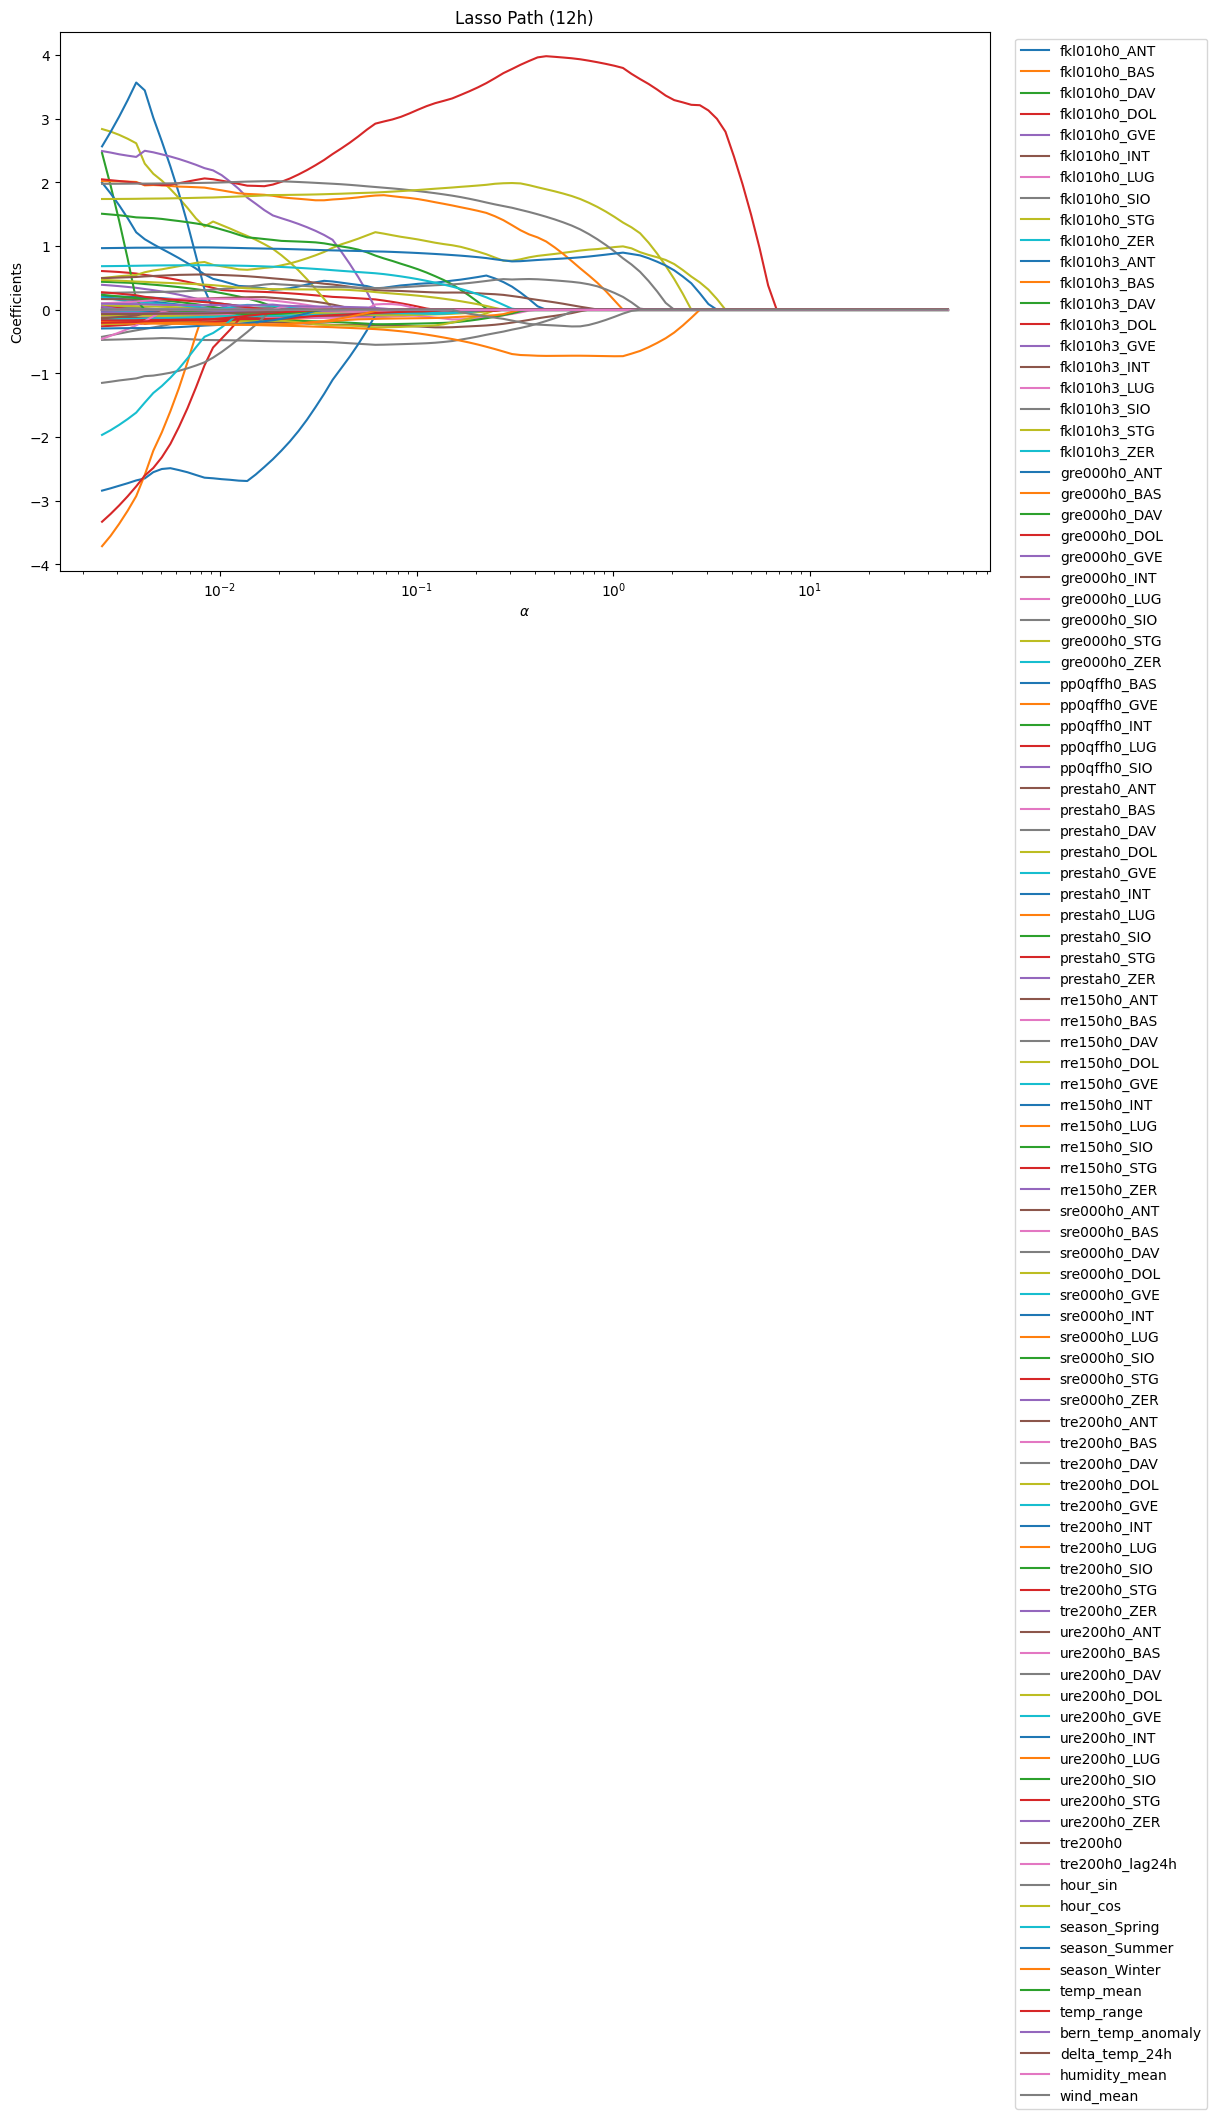

Best alpha = 0.0025118864315095794
1-SE alpha = 0.006828784919782344
Nombre de variables sélectionnées : 73
Variables sélectionnées : ['fkl010h0_ANT', 'fkl010h0_BAS', 'fkl010h0_DOL', 'fkl010h0_GVE', 'fkl010h0_INT', 'fkl010h0_LUG', 'fkl010h0_STG', 'fkl010h3_ANT', 'fkl010h3_BAS', 'fkl010h3_DAV', 'fkl010h3_DOL', 'fkl010h3_GVE', 'fkl010h3_INT', 'fkl010h3_LUG', 'fkl010h3_SIO', 'fkl010h3_STG', 'fkl010h3_ZER', 'gre000h0_ANT', 'gre000h0_DAV', 'gre000h0_GVE', 'gre000h0_INT', 'gre000h0_LUG', 'gre000h0_SIO', 'gre000h0_STG', 'gre000h0_ZER', 'pp0qffh0_BAS', 'pp0qffh0_GVE', 'pp0qffh0_LUG', 'prestah0_DOL', 'prestah0_INT', 'prestah0_STG', 'prestah0_ZER', 'rre150h0_ANT', 'rre150h0_BAS', 'rre150h0_DAV', 'rre150h0_DOL', 'rre150h0_INT', 'rre150h0_LUG', 'rre150h0_STG', 'rre150h0_ZER', 'sre000h0_ANT', 'sre000h0_BAS', 'sre000h0_DAV', 'sre000h0_DOL', 'sre000h0_GVE', 'sre000h0_INT', 'sre000h0_LUG', 'sre000h0_SIO', 'sre000h0_STG', 'tre200h0_DAV', 'tre200h0_DOL', 'tre200h0_GVE', 'tre200h0_INT', 'tre200h0_LUG', '

/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.169e+03, tolerance: 3.506e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.607e+02, tolerance: 3.562e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

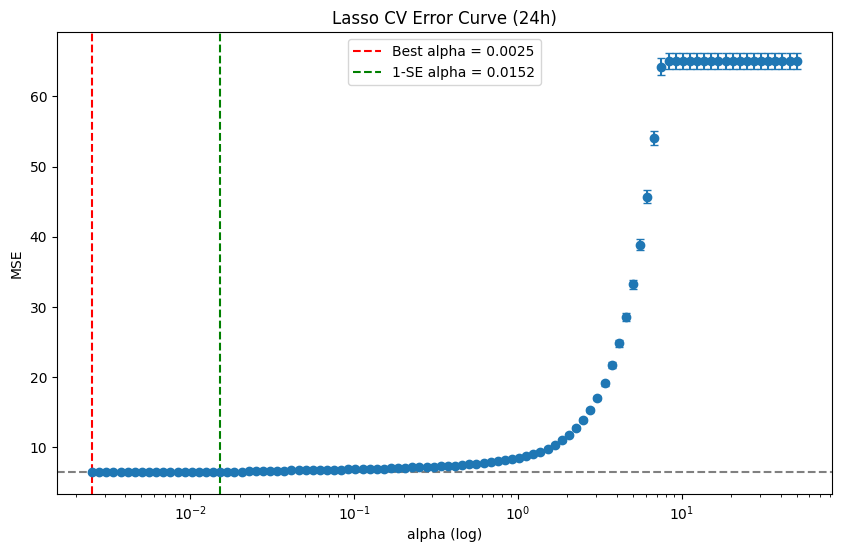

/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.310e+03, tolerance: 3.941e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.746e+02, tolerance: 3.941e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

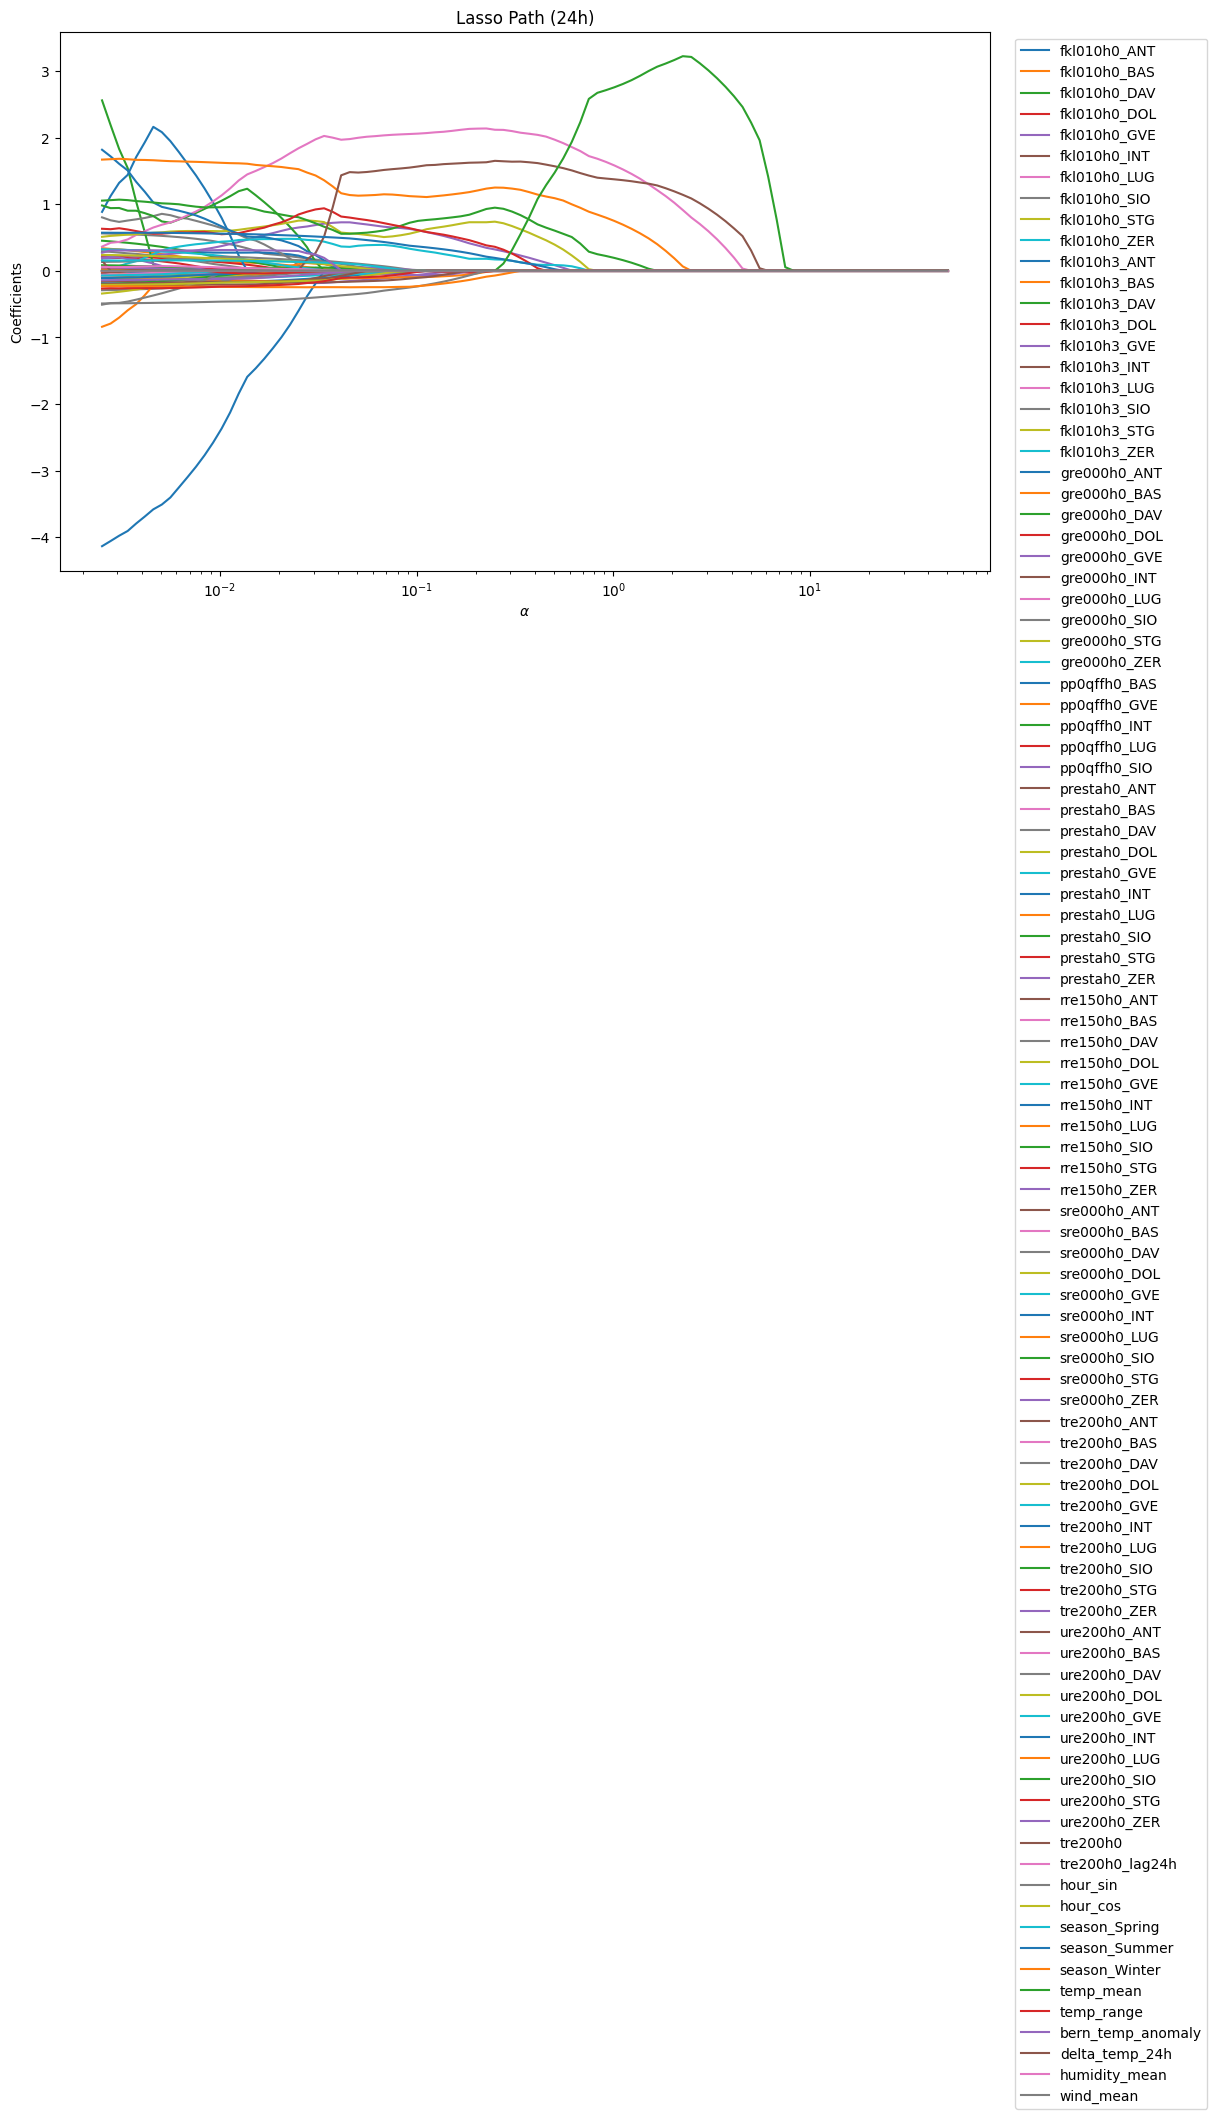

Best alpha = 0.0025118864315095794
1-SE alpha = 0.01519911082952933
Nombre de variables sélectionnées : 52
Variables sélectionnées : ['fkl010h0_BAS', 'fkl010h0_GVE', 'fkl010h0_SIO', 'fkl010h3_ANT', 'fkl010h3_BAS', 'fkl010h3_DAV', 'fkl010h3_INT', 'fkl010h3_LUG', 'fkl010h3_SIO', 'fkl010h3_STG', 'fkl010h3_ZER', 'gre000h0_ANT', 'gre000h0_BAS', 'gre000h0_DAV', 'gre000h0_DOL', 'gre000h0_GVE', 'gre000h0_SIO', 'pp0qffh0_BAS', 'prestah0_DAV', 'prestah0_SIO', 'rre150h0_DAV', 'rre150h0_DOL', 'rre150h0_GVE', 'rre150h0_SIO', 'rre150h0_ZER', 'sre000h0_ANT', 'sre000h0_DAV', 'sre000h0_DOL', 'sre000h0_GVE', 'sre000h0_INT', 'sre000h0_SIO', 'sre000h0_ZER', 'tre200h0_BAS', 'tre200h0_DOL', 'tre200h0_GVE', 'tre200h0_INT', 'tre200h0_LUG', 'tre200h0_SIO', 'tre200h0_STG', 'ure200h0_ANT', 'ure200h0_DAV', 'ure200h0_DOL', 'ure200h0_INT', 'ure200h0_STG', 'tre200h0_lag24h', 'hour_sin', 'hour_cos', 'season_Spring', 'season_Summer', 'season_Winter', 'temp_range', 'bern_temp_anomaly']

TRAIN → MAE: 1.9503
TEST  → MAE:

/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.131e+02, tolerance: 3.502e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.478e+03, tolerance: 3.539e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

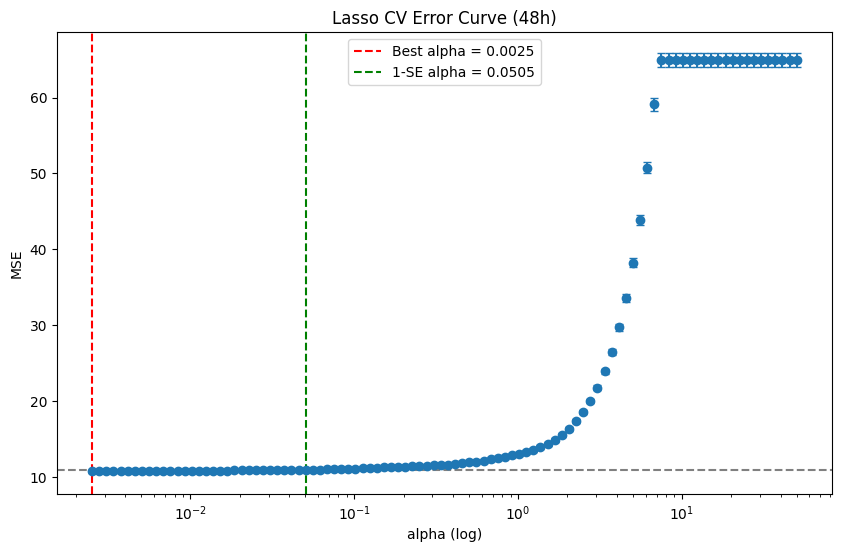

/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.865e+02, tolerance: 3.936e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.048e+03, tolerance: 3.936e+01
  model = cd_fast.enet_coordinate_descent(
/Users/ayamarkous/Desktop/ML 2025/MLProject/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

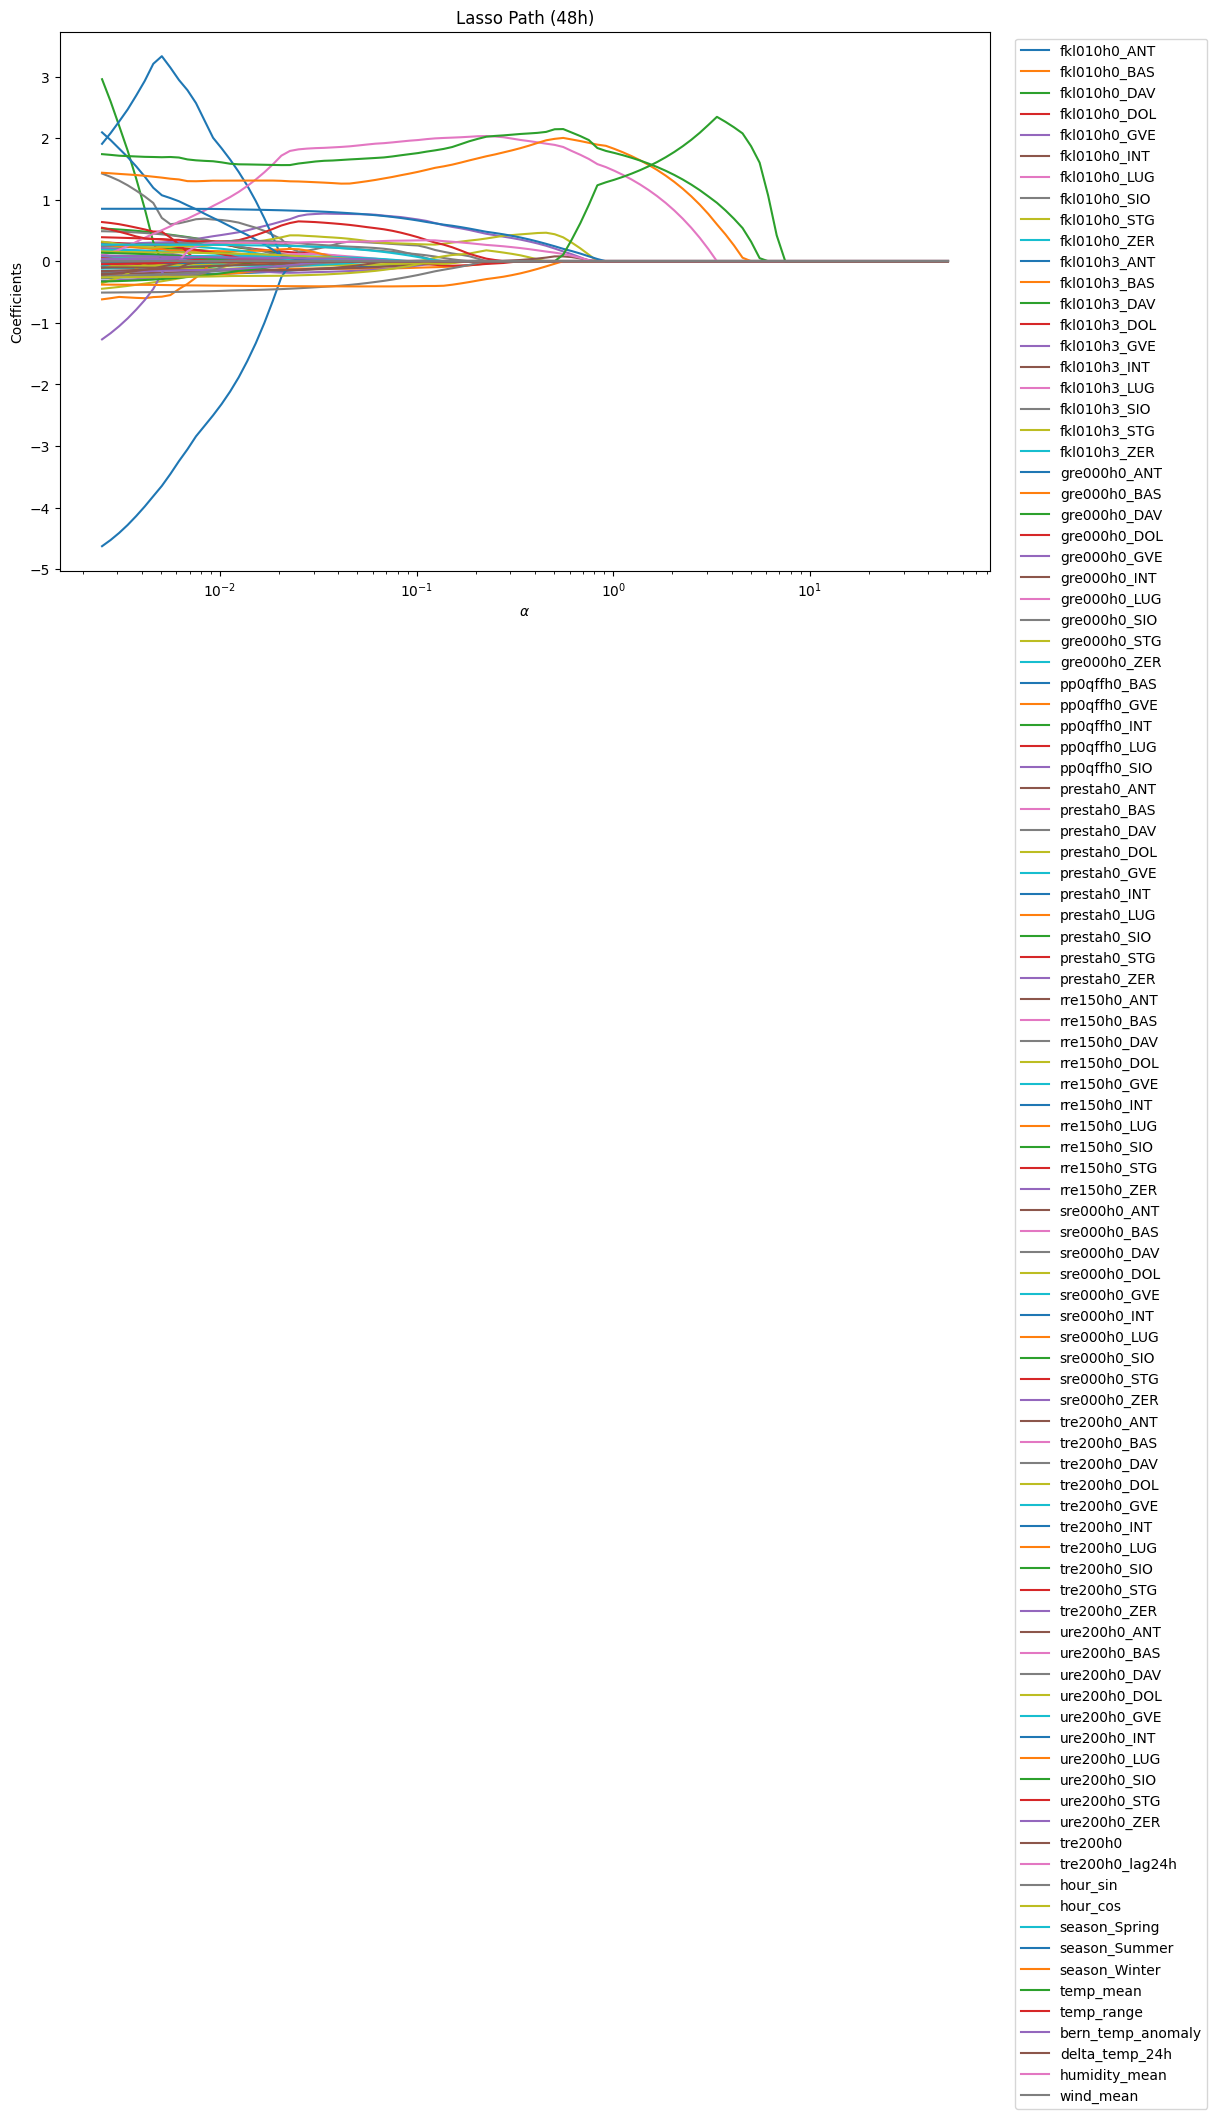

Best alpha = 0.0025118864315095794
1-SE alpha = 0.050469651168843936
Nombre de variables sélectionnées : 32
Variables sélectionnées : ['fkl010h0_ANT', 'fkl010h0_BAS', 'fkl010h0_GVE', 'fkl010h0_SIO', 'fkl010h0_STG', 'fkl010h3_BAS', 'fkl010h3_INT', 'fkl010h3_STG', 'fkl010h3_ZER', 'gre000h0_DOL', 'gre000h0_GVE', 'gre000h0_LUG', 'prestah0_DAV', 'rre150h0_DAV', 'rre150h0_GVE', 'rre150h0_INT', 'sre000h0_ANT', 'tre200h0_BAS', 'tre200h0_DOL', 'tre200h0_GVE', 'tre200h0_LUG', 'tre200h0_SIO', 'tre200h0_STG', 'ure200h0_DAV', 'ure200h0_DOL', 'ure200h0_ZER', 'tre200h0_lag24h', 'hour_sin', 'hour_cos', 'season_Spring', 'season_Summer', 'season_Winter']

TRAIN → MAE: 2.6094
TEST  → MAE: 2.5770


In [60]:
res_12 = run_lasso_full(X_train_12, y_train_12, X_test_12, y_test_12, "12h")
res_24 = run_lasso_full(X_train_24, y_train_24, X_test_24, y_test_24, "24h")
res_48 = run_lasso_full(X_train_48, y_train_48, X_test_48, y_test_48, "48h")

lasso_results = {
    "12": res_12,
    "24": res_24,
    "48": res_48
} 

The CV error curves show that the error does not change much around the minimum, meaning the model is not very sensitive to the exact value of α. 
As α increases, the Lasso paths show that many coefficients gradually shrink to zero, leading to simpler models.

###  Lasso Summary
A small helper function that shows how many features were selected by Lasso compared to the total, plus the percentage.

In [61]:
def lasso_summary(X_train, result, label):
    total = X_train.shape[1]
    selected = len(result["selected_features"])
    print(f"\n===== {label} =====")
    print("Total features:   ", total)
    print("Selected features:", selected)
    print("Percentage:", round(selected / total * 100, 2), "%")

lasso_summary(X_train_12, res_12, "12h")
lasso_summary(X_train_24, res_24, "24h")
lasso_summary(X_train_48, res_48, "48h")


===== 12h =====
Total features:    98
Selected features: 73
Percentage: 74.49 %

===== 24h =====
Total features:    98
Selected features: 52
Percentage: 53.06 %

===== 48h =====
Total features:    98
Selected features: 32
Percentage: 32.65 %


###  Selected Features by Lasso  
Here we extract the non-zero coefficients from the best Lasso models at **12h, 24h, and 48h**, to identify which features were selected at each time horizon.


In [62]:
# For 12h
best_model_12 = lasso_results["12"]["model"]
selected_features_12 = X_train_12.columns[best_model_12.named_steps["lasso"].coef_ != 0].tolist()

# For 24h
best_model_24 = lasso_results["24"]["model"]
selected_features_24 = X_train_24.columns[best_model_24.named_steps["lasso"].coef_ != 0].tolist()

# For 48h
best_model_48 = lasso_results["48"]["model"]
selected_features_48 = X_train_48.columns[best_model_48.named_steps["lasso"].coef_ != 0].tolist()

print("Selected Features 12h :", selected_features_12)
print("Selected Features 24h :", selected_features_24)
print("Selected Features 48h :", selected_features_48)

Selected Features 12h : ['fkl010h0_ANT', 'fkl010h0_BAS', 'fkl010h0_DOL', 'fkl010h0_GVE', 'fkl010h0_INT', 'fkl010h0_LUG', 'fkl010h0_STG', 'fkl010h3_ANT', 'fkl010h3_BAS', 'fkl010h3_DAV', 'fkl010h3_DOL', 'fkl010h3_GVE', 'fkl010h3_INT', 'fkl010h3_LUG', 'fkl010h3_SIO', 'fkl010h3_STG', 'fkl010h3_ZER', 'gre000h0_ANT', 'gre000h0_DAV', 'gre000h0_GVE', 'gre000h0_INT', 'gre000h0_LUG', 'gre000h0_SIO', 'gre000h0_STG', 'gre000h0_ZER', 'pp0qffh0_BAS', 'pp0qffh0_GVE', 'pp0qffh0_LUG', 'prestah0_DOL', 'prestah0_INT', 'prestah0_STG', 'prestah0_ZER', 'rre150h0_ANT', 'rre150h0_BAS', 'rre150h0_DAV', 'rre150h0_DOL', 'rre150h0_INT', 'rre150h0_LUG', 'rre150h0_STG', 'rre150h0_ZER', 'sre000h0_ANT', 'sre000h0_BAS', 'sre000h0_DAV', 'sre000h0_DOL', 'sre000h0_GVE', 'sre000h0_INT', 'sre000h0_LUG', 'sre000h0_SIO', 'sre000h0_STG', 'tre200h0_DAV', 'tre200h0_DOL', 'tre200h0_GVE', 'tre200h0_INT', 'tre200h0_LUG', 'tre200h0_SIO', 'tre200h0_STG', 'ure200h0_ANT', 'ure200h0_BAS', 'ure200h0_DAV', 'ure200h0_DOL', 'ure200h0_INT',

In [63]:

selected_features_12 = lasso_results["12"]["selected_features"]

X_train_12_sel = X_train_12_scaled[selected_features_12]
X_test_12_sel  = X_test_12_scaled[selected_features_12]

print("X_train_12_sel shape:", X_train_12_sel.shape)
print("X_test_12_sel shape :", X_test_12_sel.shape)


selected_features_24 = lasso_results["24"]["selected_features"]

X_train_24_sel = X_train_24_scaled[selected_features_24]
X_test_24_sel  = X_test_24_scaled[selected_features_24]

print("X_train_24_sel shape:", X_train_24_sel.shape)
print("X_test_24_sel shape :", X_test_24_sel.shape)


selected_features_48 = lasso_results["48"]["selected_features"]

X_train_48_sel = X_train_48_scaled[selected_features_48]
X_test_48_sel  = X_test_48_scaled[selected_features_48]

print("X_train_48_sel shape:", X_train_48_sel.shape)
print("X_test_48_sel shape :", X_test_48_sel.shape)

X_train_12_sel shape: (6063, 73)
X_test_12_sel shape : (1516, 73)
X_train_24_sel shape: (6063, 52)
X_test_24_sel shape : (1516, 52)
X_train_48_sel shape: (6063, 32)
X_test_48_sel shape : (1516, 32)


## Deep Neural Network Fitting

A **Deep Neural Network (DNN)** is a flexible non-linear model composed of multiple fully connected layers.  

Two different feature settings are considered:

1. **Full feature set**: the neural network is trained using all available predictors.
2. **Lasso-selected features**: the neural network is trained using a reduced subset of variables selected via **Lasso regression**, which performs feature selection by shrinking irrelevant coefficients to zero.

By keeping the network architecture fixed and only varying the input feature space, this approach allows us to assess the impact of feature selection on the performance of deep learning models.

1. Fitting of NN with all features 

In [64]:
from tensorflow import keras

def run_dnn_horizon(
    X_train,
    y_train,
    X_test,
    y_test,
    horizon_label,
    val_ratio=0.2,
    epochs=200,
    learning_rate=0.001
):
    print(f"\n================ DNN MODEL – {horizon_label} =================\n")

    
    # Train / Validation split
   
    n_val = int(len(X_train) * val_ratio)

    X_valid = X_train[-n_val:]
    y_valid = y_train[-n_val:]

    X_train_nn = X_train[:-n_val]
    y_train_nn = y_train[:-n_val]

   
    # Model definition (same architecture)
    
    n_features = X_train_nn.shape[1]

    model = keras.models.Sequential([
        keras.layers.Input(shape=[n_features]),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1)
    ])

    model.compile(
        loss="mse",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["mae"]
    )

    # Callbacks
    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        f"best_model_{horizon_label}.keras", save_best_only=True
    )
    early_stopping_cb = keras.callbacks.EarlyStopping(
        patience=15, restore_best_weights=True
    )
    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=5, min_lr=1e-5
    )

    
    # Training
   
    history = model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=0
    )

    
    # Evaluation
  
    train_loss, train_mae = model.evaluate(X_train_nn, y_train_nn, verbose=0)
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

    print(f"{horizon_label} → TRAIN MAE : {train_mae:.4f}")
    print(f"{horizon_label} → TEST  MAE : {test_mae:.4f}")

    return {
        "horizon": horizon_label,
        "model": model,
        "history": history,
        "train_mae": train_mae,
        "test_mae": test_mae
    }

In [65]:
results_12 = run_dnn_horizon(
    X_train_12, y_train_12,
    X_test_12, y_test_12,
    horizon_label="12h"
)

results_24 = run_dnn_horizon(
    X_train_24, y_train_24,
    X_test_24, y_test_24,
    horizon_label="24h"
)

results_48 = run_dnn_horizon(
    X_train_48, y_train_48,
    X_test_48, y_test_48,
    horizon_label="48h"
)


================ DNN MODEL – 12h =================

12h → TRAIN MAE : 2.9359
12h → TEST  MAE : 2.8446

================ DNN MODEL – 24h =================

24h → TRAIN MAE : 2.5223
24h → TEST  MAE : 2.5975

================ DNN MODEL – 48h =================

48h → TRAIN MAE : 2.7628
48h → TEST  MAE : 2.7413


#### DNN fitting with selected features from Lasso

In [66]:
def run_dnn_lasso_selected(
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    horizon_label,
    val_ratio=0.2,
    epochs=200,
    learning_rate=0.001
):
    print(f"\n================ DNN (LASSO SELECTED) – {horizon_label} =================\n")

   
    # Train / Validation split
   
    n_val = int(len(X_train_sel) * val_ratio)

    X_valid = X_train_sel[-n_val:]
    y_valid = y_train[-n_val:]

    X_train_nn = X_train_sel[:-n_val]
    y_train_nn = y_train[:-n_val]

    
    # DNN Model (same architecture)
   
    n_features = X_train_nn.shape[1]

    model = keras.models.Sequential([
        keras.layers.Input(shape=[n_features]),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1)
    ])

    model.compile(
        loss="mse",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["mae"]
    )

    # Callbacks
    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        f"best_model_lasso_{horizon_label}.keras",
        save_best_only=True
    )

    early_stopping_cb = keras.callbacks.EarlyStopping(
        patience=15,
        restore_best_weights=True
    )

    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )

    # Training
    history = model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=0
    )

    # Evaluation

    train_loss, train_mae = model.evaluate(
        X_train_nn, y_train_nn, verbose=0
    )

    test_loss, test_mae = model.evaluate(
        X_test_sel, y_test, verbose=0
    )

    print(f"{horizon_label} → TRAIN MAE : {train_mae:.4f}")
    print(f"{horizon_label} → TEST  MAE : {test_mae:.4f}")

    return {
        "horizon": horizon_label,
        "model": model,
        "history": history,
        "train_mae": train_mae,
        "test_mae": test_mae
    }

In [67]:
results_12_lasso = run_dnn_lasso_selected(
    X_train_12_sel,
    y_train_12,
    X_test_12_sel,
    y_test_12,
    horizon_label="12h (Lasso)"
)

results_24_lasso = run_dnn_lasso_selected(
    X_train_24_sel,
    y_train_24,
    X_test_24_sel,
    y_test_24,
    horizon_label="24h (Lasso)"
)

results_48_lasso = run_dnn_lasso_selected(
    X_train_48_sel,
    y_train_48,
    X_test_48_sel,
    y_test_48,
    horizon_label="48h (Lasso)"
)



================ DNN (LASSO SELECTED) – 12h (Lasso) =================

12h (Lasso) → TRAIN MAE : 1.4164
12h (Lasso) → TEST  MAE : 1.5564

================ DNN (LASSO SELECTED) – 24h (Lasso) =================

24h (Lasso) → TRAIN MAE : 1.7204
24h (Lasso) → TEST  MAE : 1.9426

================ DNN (LASSO SELECTED) – 48h (Lasso) =================

48h (Lasso) → TRAIN MAE : 2.3864
48h (Lasso) → TEST  MAE : 2.5097


##### Impact of Lasso Feature Selection on DNN Performance

The results show that the **Deep Neural Network trained on Lasso-selected features significantly outperforms the model trained on the full feature set**, especially for the **12-hour and 24-hour forecasting horizons**.

This improvement can be explained by several factors:

- **Reduction of noise and irrelevant variables**:  
  Lasso removes predictors with weak or redundant information, allowing the neural network to focus on the most informative features.

- **Lower model complexity**:  
  By reducing the dimensionality of the input space, the DNN becomes less prone to overfitting, which is particularly beneficial for shorter horizons where signal-to-noise ratios are higher.

- **Improved bias–variance trade-off**:  
  Although feature selection may slightly increase bias, it substantially reduces variance, leading to better generalization performance on the test set.

- **More stable training dynamics**:  
  With fewer input variables, gradient updates are more stable and the optimization process converges more efficiently.

The performance gains are most pronounced for the **12h and 24h horizons**, where the predictive structure is captured more effectively by a compact set of relevant features.  
For longer horizons (48h), the advantage of feature selection is less pronounced, as the underlying relationships become more complex and harder to model.

